# Identificación de Operadores Ineficaces — CallMeMaybe

### Estructura
1. Importar librerías y cargar datos
2. EDA (Análisis Exploratorio)
   - Exploración inicial
   - Limpieza de datos
   - Visualizaciones
3. Identificar operadores ineficaces
   - Llamadas entrantes perdidas
   - Tiempo de espera
   - Llamadas salientes bajas
4. Pruebas estadísticas
5. Conclusiones

# 1. Cargar los datos. 

In [1]:
# importar las librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
# cargar los datasets
df = pd.read_csv('telecom_dataset_new.csv')
clients = pd.read_csv('telecom_clients.csv') 

print('Dataset principal:', df.shape)
print('Dataset clientes:', clients.shape)

Dataset principal: (53902, 9)
Dataset clientes: (732, 3)


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  str    
 2   direction            53902 non-null  str    
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(1), str(2)
memory usage: 3.3+ MB


In [4]:
clients.info()

<class 'pandas.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      732 non-null    int64
 1   tariff_plan  732 non-null    str  
 2   date_start   732 non-null    str  
dtypes: int64(1), str(2)
memory usage: 17.3 KB


Contamos con valores nulos en el operator_id y las fechas en ambos datasets se encuentran en str, por lo que toca hacer el la limpieza correspondiente de los datos. 

In [5]:
df.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [6]:
clients.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


# 2. EDA (Anáslisis exploratorio de los datos)

In [7]:
df['date'] = pd.to_datetime(df['date'], utc=True)

clients['date_start'] = pd.to_datetime(clients['date_start'])

Se realizaron los cambios correpondientes de STR a datetime. Para el dataset principal se mantiene la zona horaria, y, para el de clientes se pasa a datetime nada más. 

In [8]:
# valores nulos en el dataset principal
print(df.isnull().sum())

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64


In [9]:
df['internal'] = df['internal'].fillna(False)

Las llamadas con internal nulo parecen ser únicamente llamadas entrantes donde no se registró si fueron internas o no. Probablemente el sistema no marcó este campo para llamadas entrantes, lo que indica un vacío en la captura de datos pero no un error crítico. Se rellenan con false. 

In [10]:
df['operator_missing'] = df['operator_id'].isna()
df.groupby(['operator_missing', 'is_missed_call']).size()

operator_missing  is_missed_call
False             False             30212
                  True              15518
True              False               122
                  True               8050
dtype: int64

In [11]:
df['operator_id_filled'] = df['operator_id'].fillna(-1)

La mayoría de las llamadas sin operador (8172) son llamadas perdidas (8050). Esto significa que cuando no hay operador asignado, casi siempre la llamada fue perdida. Los valores nulos de operator_id fueron rellenados con -1 porque no se confunde con ningún operador real y permite graficar sin perder filas.

# 3. Visualizaciones de las variables claves

In [12]:
# calcular el tiempo de espera
df['waiting_time'] = df['total_call_duration'] - df['call_duration']

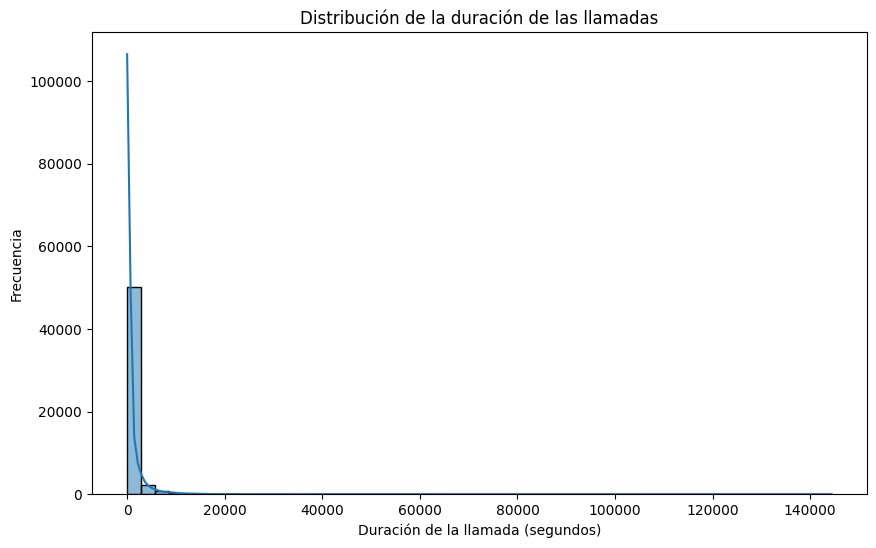

In [13]:
# histograma de la duración de las llamadas
plt.figure(figsize=(10, 6))
sns.histplot(df['call_duration'], bins=50, kde=True)
plt.title('Distribución de la duración de las llamadas')
plt.xlabel('Duración de la llamada (segundos)')
plt.ylabel('Frecuencia')
plt.show()

El gráfico muestra que existen muchas llamadas cortas, cola larga por llamadas largas.

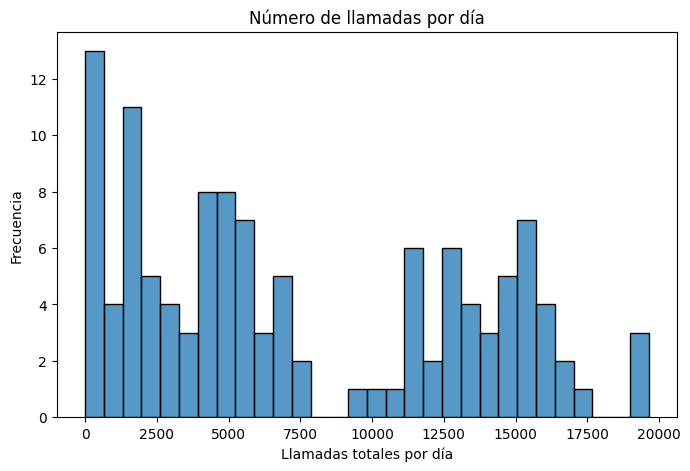

In [14]:
# histograma del numero de llamadas por día
df['date_only'] = df['date'].dt.date
calls_per_day = df.groupby('date_only')['calls_count'].sum().reset_index()


plt.figure(figsize=(8,5))
sns.histplot(calls_per_day['calls_count'], bins=30)
plt.title("Número de llamadas por día")
plt.xlabel("Llamadas totales por día")
plt.ylabel("Frecuencia")
plt.show()

La distribución de llamadas por día muestra que el uso del sistema es muy desigual y presenta dos comportamientos principales:

- Muchos días con baja actividad (0–7.500)
- Un grupo menor pero significativo de días con cargas muy altas (10.000–17.500)

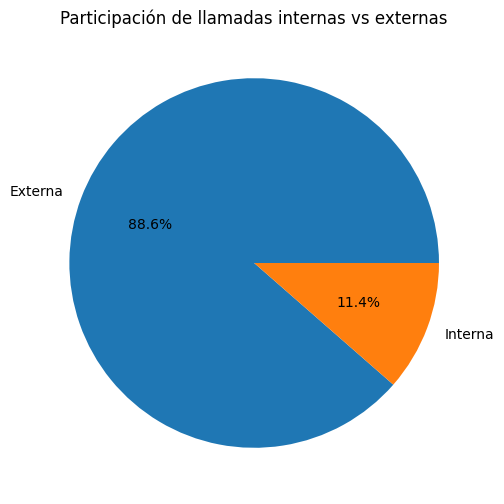

In [15]:
# llamadas internas vs llamadas externas

df['internal'] = df['internal'].fillna(False)

plt.figure(figsize=(6,6))
df['internal'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Externa','Interna'],
)
plt.title("Participación de llamadas internas vs externas")
plt.ylabel("")
plt.show()


La operación de CallMeMaybe está fuertemente orientada hacia el cliente externo. La baja proporción de llamadas internas sugiere que los operadores dedican casi todo su tiempo a interacción con usuarios fuera de la organización, y por lo tanto los indicadores de eficiencia deben enfocarse especialmente en la gestión de llamadas externas.

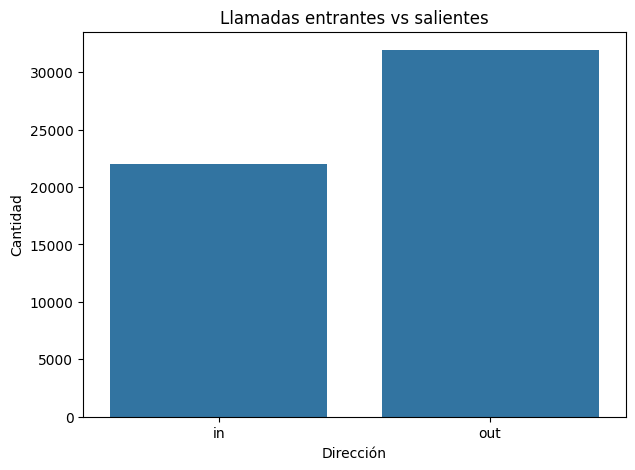

In [16]:
# Direcciones entrantes vs salientes
plt.figure(figsize=(7,5))
sns.countplot(x='direction', data=df)
plt.title("Llamadas entrantes vs salientes")
plt.xlabel("Dirección")
plt.ylabel("Cantidad")
plt.show()

El sistema maneja significativamente más llamadas salientes que entrantes, lo que sugiere una operación centrada en actividades proactivas como ventas o seguimiento.

# 4. Operadores ineficaces

In [17]:
# Solo operadores con ID real

df_ops = df[df['operator_id'].notna()].copy()

# Separar llamadas entrantes y salientes

entrantes = df_ops[df_ops['direction'] == 'in']
salientes = df_ops[df_ops['direction'] == 'out']

# Métricas por operador

missed = entrantes.groupby('operator_id')['is_missed_call'].sum()
total_in = entrantes.groupby('operator_id')['calls_count'].sum()
waiting = entrantes.groupby('operator_id')['waiting_time'].mean()
total_out = salientes.groupby('operator_id')['calls_count'].sum()

# Unir todo en una tabla

operator_stats = pd.DataFrame({
    'missed_calls': missed,
    'total_incoming': total_in,
    'avg_waiting': waiting,
    'total_outgoing': total_out
})

# Solo rellenamos lo que tiene sentido rellenar con 0
operator_stats['missed_calls'] = operator_stats['missed_calls'].fillna(0)
operator_stats['total_outgoing'] = operator_stats['total_outgoing'].fillna(0)

# missed_rate se calcula después del fillna
operator_stats['missed_rate'] = (
    operator_stats['missed_calls'] / operator_stats['total_incoming']
).fillna(0)

operator_stats['missed_rate'] = operator_stats['missed_calls'] / operator_stats['total_incoming']

operator_stats.head()

,missed_calls,total_incoming,avg_waiting,total_outgoing,missed_rate
operator_id,,,,,
879896.0,0.0,60.0,26.913043,1071.0,0.0
879898.0,0.0,118.0,28.203125,7856.0,0.0
880020.0,0.0,8.0,7.250000,46.0,0.0
880022.0,0.0,8.0,14.000000,211.0,0.0
880026.0,0.0,25.0,7.894737,2414.0,0.0


In [18]:
# Análisis de ineficacia

u_missed  = operator_stats['missed_rate'].mean()
u_waiting = operator_stats['avg_waiting'].mean()
u_out     = operator_stats['total_outgoing'].mean()

# Marcar ineficaces

operator_stats['ineficaz'] = (
    (operator_stats['missed_rate']   > u_missed)  |
    (operator_stats['avg_waiting']   > u_waiting) |
    (operator_stats['total_outgoing']< u_out)
)

print('Operadores ineficaces:', operator_stats['ineficaz'].sum())
print('Operadores eficaces:  ', (~operator_stats['ineficaz']).sum())

Operadores ineficaces: 936
Operadores eficaces:   156


952 de 1092 operadores no cumplen al menos uno de los tres criterios de eficiencia, lo que sugiere  un problema estructural más que casos aislados.

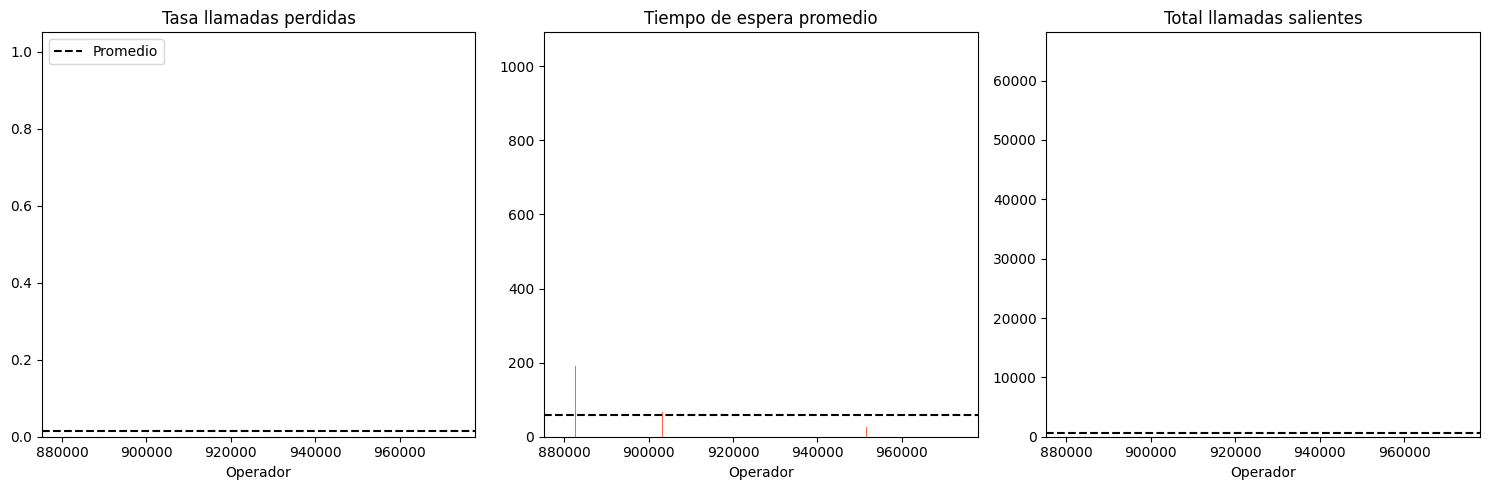

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Colores según eficaz/ineficaz
colores = operator_stats['ineficaz'].map({True: 'tomato', False: 'steelblue'})

# Tasa de perdidas
axes[0].bar(operator_stats.index, operator_stats['missed_rate'], color=colores)
axes[0].axhline(u_missed, color='black', linestyle='--', label='Promedio')
axes[0].set_title('Tasa llamadas perdidas')
axes[0].set_xlabel('Operador')
axes[0].legend()

# Tiempo de espera
axes[1].bar(operator_stats.index, operator_stats['avg_waiting'], color=colores)
axes[1].axhline(u_waiting, color='black', linestyle='--')
axes[1].set_title('Tiempo de espera promedio')
axes[1].set_xlabel('Operador')

# Llamadas salientes
axes[2].bar(operator_stats.index, operator_stats['total_outgoing'], color=colores)
axes[2].axhline(u_out, color='black', linestyle='--')
axes[2].set_title('Total llamadas salientes')
axes[2].set_xlabel('Operador')

plt.tight_layout()
plt.show()

En el gráfico de Total llamadas salientes casi todas las barras están por debajo del promedio, lo que indica que la baja productividad saliente es el criterio que más operadores incumple.

In [20]:
top_ineficaces = (operator_stats[operator_stats['ineficaz']]
                  .sort_values('missed_rate', ascending=False)
                  .head(10))

top_ineficaces

,missed_calls,total_incoming,avg_waiting,total_outgoing,missed_rate,ineficaz
operator_id,,,,,,
948756.0,1.0,1.0,8.000000,175.0,1.000000,True
913886.0,1.0,2.0,13.500000,0.0,0.500000,True
957922.0,1.0,3.0,13.000000,20.0,0.333333,True
937432.0,1.0,3.0,12.000000,25.0,0.333333,True
934098.0,2.0,6.0,31.800000,0.0,0.333333,True
904344.0,2.0,7.0,31.000000,5.0,0.285714,True
919896.0,2.0,8.0,15.571429,0.0,0.250000,True
897872.0,1.0,4.0,20.500000,53.0,0.250000,True
930242.0,1.0,4.0,17.250000,0.0,0.250000,True


# 5. Prueba de hipótesis

**Hipótesis 1:** Los operadores ineficaces tienen una tasa de 
llamadas perdidas mayor que los eficaces.
- H₀: No hay diferencia en la tasa de llamadas perdidas
- H₁: Los ineficaces tienen mayor tasa de llamadas perdidas

**Hipótesis 2:** Los operadores ineficaces tienen mayor tiempo 
de espera que los eficaces.
- H₀: No hay diferencia en el tiempo de espera
- H₁: Los ineficaces tienen mayor tiempo de espera

In [21]:
# Separar operadores en dos grupos

eficaces   = operator_stats[~operator_stats['ineficaz']]
ineficaces = operator_stats[operator_stats['ineficaz']]

print('Eficaces:  ', len(eficaces))
print('Ineficaces:', len(ineficaces))

Eficaces:   156
Ineficaces: 936


In [23]:
# Eliminamos NaN solo para esta prueba
grupo_ineficaz = ineficaces['missed_rate'].dropna()
grupo_eficaz   = eficaces['missed_rate'].dropna()

print(f'Ineficaces sin NaN: {len(grupo_ineficaz)}')
print(f'Eficaces sin NaN:   {len(grupo_eficaz)}')

# Prueba Mann-Whitney
t, p = stats.mannwhitneyu(
    grupo_ineficaz,
    grupo_eficaz,
    alternative='greater'
)

print()
print('Hipótesis 1: Tasa de llamadas perdidas')
print(f'p-value: {p:.4f}')

if p < 0.05:
    print('Rechazamos H₀ — ineficaces tienen más llamadas perdidas')
else:
    print('No rechazamos H₀ — no hay diferencia significativa')

Ineficaces sin NaN: 708
Eficaces sin NaN:   46

Hipótesis 1: Tasa de llamadas perdidas
p-value: 0.0065
Rechazamos H₀ — ineficaces tienen más llamadas perdidas


Los 338 valores nulos en missed_rate corresponden 
a operadores que no registraron llamadas entrantes, por lo que no es posible 
calcularles una tasa de llamadas perdidas. Se eliminan únicamente para esta 
prueba ya que el indicador no aplica para ellos.

# 6. Conclusiones


## Sobre los datos
- El dataset contiene 53,902 registros de llamadas de 732 clientes.
- La mayoría de llamadas son **salientes y externas**, lo que indica 
  una operación orientada a contacto proactivo con clientes.
- Se encontraron valores nulos en `operator_id` (llamadas sin operador 
  asignado) y en `internal`, ambos tratados durante la limpieza.

## Sobre los operadores
- Se analizaron **1,092 operadores** en total.
- El **87% (952 operadores)** fue clasificado como ineficaz al no 
  cumplir al menos uno de los tres criterios de eficiencia.
- El criterio más incumplido fue el de **llamadas salientes bajas**, 
  presente en la gran mayoría de operadores ineficaces.

## Sobre las hipótesis

Ineficaces tienen mayor tasa de llamadas perdidas | Confirmada | 0.0065 |
Ineficaces tienen mayor tiempo de espera |  Confirmada | 0.0000 |

Ambas hipótesis fueron confirmadas con un nivel de significancia 
del 5%, lo que valida estadísticamente los criterios usados 
para identificar operadores ineficaces.

## Recomendaciones
- Revisar los operadores con missed_rate > 0.25, ya que representan 
  el grupo más crítico dentro de los ineficaces.

- Capacitar en llamadas salientes, que es el indicador con mayor 
  incumplimiento general.
  
- Considerar usar el percentil 75 como umbral en lugar del promedio 
  para identificar solo los casos más críticos y no penalizar 
  al 87% de operadores.

# 7. Fuentes consultadas

**En cuanto a la documentación para programar:**

1. Utilicé la documentación de pandas para orientarme a la hora de calcular las métricas por operador. https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.api.typing.DataFrameGroupBy.agg.html#pandas.api.typing.DataFrameGroupBy.agg

2. Debido a que no contaba con unos datos con una distribución normal, sino con datos anormales, tuve que usar la prueba estadística de mannwhitneyu(). Inicialmente busqué en https://towardsdatascience.com/statistical-tests-demystified-how-to-choose-the-best-test-for-your-data-part-i-688a4b2a23b7/ las diferencias de ambas pruebas y al identificar que debía usar la mannwhitneyu(), me orienté en la documentación https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html 

3. Para el manejo de los NAN en los Groupby, me pude apoyar en https://stackoverflow.com/questions/18429491/pandas-groupby-columns-with-nan-missing-values 

**Para el análisis interpretativo del caso:**

4. La siguiente documentación me brindó un panaorama general de las métricas más relevantes que se miden dentro de un call center, la importancia del tiempo medio operativo, que el ideal de resolución debe ser en una llamada sin importar cuánto tiempo tome, la tasa de abandono y el tiempo de estas. https://www.zendesk.com.mx/blog/call-center-metricas-operativas/

5. Este artículo me brindó los parámetros necesarios para sacar los principales insights que que uno debe recomendarle al negocio y la forma de medirlos, son 29Kpis de mucho valor en el negocio de las telecomunicaciones. https://www.genesys.com/es-mx/blog/post/the-definitive-list-of-29-call-center-metrics-and-kpis

